# Lab Experiment: Data Collection
## Web Scraping and APIs

**Course:** Data science  Laboratory
**Class:** B.Tech
**Duration:** 2 hours

---

### Aim
To collect data from a web page and from a REST API, and save it as CSV files.

### Objectives
1. Extract data from an HTML page using **BeautifulSoup**
2. Extract a table using **pandas.read_html**
3. Collect data from a **REST API** and parse the JSON response
4. Save all collected data to CSV files

### Software Required
Python 3, `requests`, `beautifulsoup4`, `lxml`, `pandas`, `matplotlib`

### Theory

There are two ways to collect data from the internet:

| | Web Scraping | REST API |
|---|---|---|
| Data format | HTML (meant for humans) | JSON (meant for programs) |
| Tool | BeautifulSoup | requests + json |
| Effort | High | Low |
| Allowed? | Only if the site permits it | Yes, that is what it is for |

**Rule: if an API exists, use the API.** Scrape only when there is no API.

---
## Step 0: Setup

In [1]:
# Install if needed (uncomment the line below)
# !pip install requests beautifulsoup4 lxml pandas matplotlib

import io
import json
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
from pathlib import Path

# Folder to store collected data
DATA = Path("data")
DATA.mkdir(exist_ok=True)

print("Setup complete. Data will be saved in:", DATA.resolve())

Setup complete. Data will be saved in: C:\Users\btaru\data science\Lab-1 (7)\Lab-1\data


---
## Step 1: Rules Before Collecting Data

Before scraping any website, check these four things:

1. **Check `robots.txt`** — visit `https://website.com/robots.txt`. It says which pages
   crawlers may visit.
2. **Check the Terms of Service** — many Indian property sites (99acres, MagicBricks)
   do **not** allow automatic data collection.
3. **Go slow** — wait 1–2 seconds between requests. Do not send requests in a fast loop.
4. **Never collect personal data** — no names, phone numbers or email IDs.

In this lab we use a **practice HTML page created on your own computer**, so no website is
disturbed. The API we use (Open-Meteo) is free and openly allows this.

In [2]:
# Check if a website allows scraping
from urllib.robotparser import RobotFileParser

def can_scrape(url):
    rp = RobotFileParser()
    rp.set_url(url.split("/")[0] + "//" + url.split("/")[2] + "/robots.txt")
    try:
        rp.read()
        return rp.can_fetch("*", url)
    except Exception:
        return "could not check (no internet)"

print("Wikipedia :", can_scrape("https://en.wikipedia.org/wiki/Bangalore"))
print("99acres   :", can_scrape("https://www.99acres.com/property-in-bangalore-ffid"))

Wikipedia : False
99acres   : False


---
# EXPERIMENT 1
## Collecting Data from an HTML Page

We will collect Bengaluru house listings from a web page.

**How scraping works:**

```
HTML page  →  BeautifulSoup  →  find the tags  →  get the text  →  DataFrame  →  CSV
```

[![Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png](https://i.postimg.cc/NjJc6QCL/Chat-GPT-Image-Aug-13-2026-06-43-45-PM.png)](https://postimg.cc/JskvmCLW)

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# 1. URL
url = "https://quotes.toscrape.com/"

# 2. Fetch
response = requests.get(url)

# 3. Parse
soup = BeautifulSoup(response.text, "html.parser")

# 4. Find quote containers
quotes = soup.find_all("div", class_="quote")  # ← fix: div not span

# 5. Extract
data = []
for quote in quotes:
    text   = quote.find("span", class_="text").get_text(strip=True)
    author = quote.find("small", class_="author").get_text(strip=True)
    data.append({"Quote": text, "Author": author})

# 6. DataFrame
df = pd.DataFrame(data)
print(df)

# 7. Save
df.to_csv("quotes.csv", index=False)
print("Data saved to quotes.csv")

                                               Quote             Author
0  “The world as we have created it is a process ...    Albert Einstein
1  “It is our choices, Harry, that show what we t...       J.K. Rowling
2  “There are only two ways to live your life. On...    Albert Einstein
3  “The person, be it gentleman or lady, who has ...        Jane Austen
4  “Imperfection is beauty, madness is genius and...     Marilyn Monroe
5  “Try not to become a man of success. Rather be...    Albert Einstein
6  “It is better to be hated for what you are tha...         André Gide
7  “I have not failed. I've just found 10,000 way...   Thomas A. Edison
8  “A woman is like a tea bag; you never know how...  Eleanor Roosevelt
9  “A day without sunshine is like, you know, nig...       Steve Martin
Data saved to quotes.csv


In [4]:
import json
import re
import pandas as pd
 
INPUT_FILE = "data/House.html"
OUTPUT_FILE = "bengaluru_houses.csv"
 
 
# ---------- STEP 1: read the file ----------
html = open(INPUT_FILE, encoding="utf-8").read()
print("File read. Size:", len(html), "characters")
 
 
# ---------- STEP 2: cut out the JSON ----------
marker = "window.__initialData__="
start = html.find(marker) + len(marker)

File read. Size: 1774012 characters


##### Find where the marker ends; that's where the embedded data starts

In [5]:
import requests

url = "https://www.99acres.com/property-in-bangalore-ffid"

headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )
}

response = requests.get(url, headers=headers)
html = response.text
print("Page fetched. Size:", len(html), "chars")

# Find the actual JSON data marker
marker = "window.__INITIAL_STATE__ ="
marker_pos = html.find(marker)

if marker_pos == -1:
    raise ValueError("Marker not found — inspect page source to find the right marker")

start = html.index("{", marker_pos)
print("JSON start found at index:", start)

Page fetched. Size: 407 chars


ValueError: Marker not found — inspect page source to find the right marker

In [6]:
html = open("data/House.html", encoding="utf-8").read()
start = html.index("{", html.find("window.__initialData__=") + len("window.__initialData__="))

In [7]:
 
# Read forward until the opening { is closed by its matching }
depth = 0
for end in range(start, len(html)):
    if html[end] == "{":
        depth += 1
    elif html[end] == "}":
        depth -= 1
        if depth == 0:
            break
 

##### depth acts like a brace counter. It starts counting when { appears and stops when all the opened { braces have been closed by matching } braces.

In [8]:
import json
import pandas as pd

OUTPUT_FILE = "99acres_bangalore.csv"

data = json.loads(html[start:end + 1])
print("JSON loaded successfully")

# ---------- STEP 3: reach the list of properties ----------
properties = data["srp"]["pageData"]["properties"]
print("Number of listings found:", len(properties))

# ---------- STEP 4: pick the fields we want ----------
def price_in_lakh(rupees):
    """21998600 -> 220.0 lakh"""
    try:
        return round(float(rupees) / 100000, 2)
    except (TypeError, ValueError):
        return None

def to_number(value):
    """'2600' -> 2600.0 ; None -> None"""
    try:
        return float(value)
    except (TypeError, ValueError):
        return None

rows = []
for p in properties:
    rows.append({
        "location":       p.get("LOCALITY"),
        "bhk":            to_number(p.get("BEDROOM_NUM")),
        "sqft":           to_number(p.get("LOCALIZED_AREA_VALUE")),
        "area_unit":      p.get("LOCALIZED_AREA_UNIT_LABEL"),
        "price_lakh":     price_in_lakh(p.get("MIN_PRICE")),
        "price_text":     p.get("PRICE"),
        "price_per_sqft": to_number(p.get("PRICE_SQFT")),
        "property_name":  p.get("PROP_NAME"),
    })

houses = pd.DataFrame(rows)

# ---------- STEP 5: quick check ----------
print("\nAll areas in sqft?", (houses["area_unit"] == "sqft").all())
print("Missing values:\n", houses.isna().sum().to_string())

# ---------- STEP 6: save ----------
houses.to_csv(OUTPUT_FILE, index=False)
print("\nSaved", len(houses), "rows to", OUTPUT_FILE)
print(houses.head(10).to_string(index=False))

JSON loaded successfully
Number of listings found: 27

All areas in sqft? True
Missing values:
 location          0
bhk               0
sqft              0
area_unit         0
price_lakh        0
price_text        0
price_per_sqft    0
property_name     0

Saved 27 rows to 99acres_bangalore.csv
                        location  bhk   sqft area_unit  price_lakh      price_text  price_per_sqft              property_name
          Bommasandra, Bangalore  5.0 2600.0      sqft      219.99          2.2 Cr          8461.0                SKR Gardens
5th Block Hbr Layout, HBR Layout 12.0 1200.0      sqft      380.00          3.8 Cr         31666.0                           
        Sarjapur Road, Bangalore  4.0 3040.0      sqft      225.00 2.25  - 3.28 Cr          9087.0 CasaLife by Bhavisha Homes
           Whitefield, Bangalore  5.0 4629.0      sqft      381.38 3.81  - 6.65 Cr         11299.0                 DSR Elixir
           Whitefield, Bangalore  4.0 4879.5      sqft      490.53 4.91  -

##### Write a Python program that reads the provided Magicbricks HTML webpage, extracts house/property details for Bengaluru, and saves the collected information into a CSV file.

### Result — Experiment 1

**Number of listings collected:** ______

**Columns collected:** ______

**File saved:** ______

**Observation:**

> ...

---
# EXPERIMENT 2
## Collecting Data from a REST API (Weather)

We will collect Bengaluru weather data from the **Open-Meteo API**.
It is free and needs **no API key**.

**How an API call works:**

```
https://api.open-meteo.com/v1/forecast ? latitude=12.97 & longitude=77.59 & hourly=temperature_2m
|________ address of the API _________|  |____________ what we are asking for ____________|
```

The API replies with **JSON**, which Python reads as a dictionary.

**Important status codes:**

| Code | Meaning |
|------|---------|
| 200 | Success |
| 404 | Not found |
| 429 | Too many requests — slow down |
| 500 | Server problem |

[![44.png](https://i.postimg.cc/05hNftLY/44.png)](https://postimg.cc/K4rFc5cj)

In [9]:
# --- Step 2a: Ask the API for the current weather ---

URL = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude": 12.9716,        # Bengaluru
    "longitude": 77.5946,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m",
    "timezone": "Asia/Kolkata",
}

try:
    response = requests.get(URL, params=params, timeout=20)
    print("Status code:", response.status_code)
    weather = response.json()
except Exception as e:
    weather = None
    print("No internet:", e)

if weather:
    print("\nCurrent weather in Bengaluru:")
    for key, value in weather["current"].items():
        print(f"  {key:22s}: {value}")

Status code: 200

Current weather in Bengaluru:
  time                  : 2026-09-24T15:15
  interval              : 900
  temperature_2m        : 23.4
  relative_humidity_2m  : 80
  wind_speed_10m        : 13.3


In [10]:
# --- Step 2b: Collect hourly temperature for the next 7 days ---

params2 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()
    wx = pd.DataFrame(result["hourly"])       # JSON -> DataFrame
    wx["time"] = pd.to_datetime(wx["time"])
    print("Collected", len(wx), "hourly records")
except Exception as e:
    wx = pd.DataFrame()
    print("No internet — the next cell will create sample data.")

wx.head()

Collected 168 hourly records


,time,temperature_2m,relative_humidity_2m,precipitation
0,2026-09-24 00:00:00,21.3,75,0.0
1,2026-09-24 01:00:00,20.6,81,0.1
2,2026-09-24 02:00:00,20.2,87,0.5
3,2026-09-24 03:00:00,20.2,88,0.2
4,2026-09-24 04:00:00,20.0,87,0.0


In [11]:
wx.to_csv("bengaluru_weather_7day.csv", index=False)
print("Saved: bengaluru_weather_7day.csv")

Saved: bengaluru_weather_7day.csv


### Exercise 2

1. Change the latitude and longitude to **Mysuru (12.2958, 76.6394)** and collect its
   weather. Save it as `weather_mysuru.csv`.
2. Add `"wind_speed_10m"` to the `hourly` parameter and collect it too.
3. Set `"latitude": "abcd"` and run the cell. What status code do you get?
4. Using a `for` loop, collect the weather for 3 cities and combine them into one
   DataFrame. Remember to add `time.sleep(1)` inside the loop. Why is the sleep needed?

In [12]:
import requests
import pandas as pd
import time

URL = "https://api.open-meteo.com/v1/forecast"

params2 = {
    "latitude": 12.2958,        # Mysuru
    "longitude": 76.6394,
    "hourly": "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
    "timezone": "Asia/Kolkata",
    "forecast_days": 7,
}

try:
    r = requests.get(URL, params=params2, timeout=20)
    result = r.json()

    wx_mysuru = pd.DataFrame(result["hourly"])
    wx_mysuru["time"] = pd.to_datetime(wx_mysuru["time"])

    print("Collected", len(wx_mysuru), "hourly records")

    wx_mysuru.to_csv("weather_mysuru.csv", index=False)
    print("Saved as weather_mysuru.csv")

except Exception as e:
    wx_mysuru = pd.DataFrame()
    print("Error:", e)

wx_mysuru.head()


Collected 168 hourly records
Saved as weather_mysuru.csv


,time,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m
0,2026-09-24 00:00:00,21.3,85,0.0,16.7
1,2026-09-24 01:00:00,20.7,88,0.0,16.2
2,2026-09-24 02:00:00,20.6,90,0.0,16.7
3,2026-09-24 03:00:00,20.6,91,0.0,16.3
4,2026-09-24 04:00:00,20.6,90,0.0,17.7


### Result — Experiment 2

**API used:** Open-Meteo REST API (https://api.open-meteo.com/v1/forecast)

**Number of records collected:** 168 (24 hours × 7 forecast days)

**Columns collected:**  time, temperature_2m, relative_humidity_2m, precipitation

**File saved:** bengaluru_weather_7day.csv

**Observation:** The Open-Meteo API returned 168 hourly weather records for Bengaluru spanning 7 days, starting from 2026-08-14 00:00. The data was directly parsed from JSON into a pandas DataFrame, with the time column converted to proper datetime objects using pd.to_datetime(). Current conditions show a temperature of 21.6°C with very high humidity (91%) and a wind speed of 14.6 km/h, consistent with Bengaluru's monsoon season. Early morning hours (00:00–04:00) show a gradual temperature dip from 21.5°C to 20.3°C alongside rising humidity (87% → 95%), and zero precipitation in that window.

> ...

---
# EXPERIMENT 3
## Collecting Air Quality Data from an API

Same method as Experiment 2, but a different API.
This data can later be used for **air quality (AQI) prediction**.

[![34.png](https://i.postimg.cc/QCKdD5Wc/34.png)](https://postimg.cc/kR9mF2s5)

In [14]:

# --- Collect air pollution data for Bengaluru ---

AQ_URL = "https://air-quality-api.open-meteo.com/v1/air-quality"

params3 = {
    "latitude": 12.9716,
    "longitude": 77.5946,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone",
    "timezone": "Asia/Kolkata",
    "past_days": 7,
}

try:
    r = requests.get(AQ_URL, params=params3, timeout=20)
    print("Status code:", r.status_code)
    aq = pd.DataFrame(r.json()["hourly"])
    aq["time"] = pd.to_datetime(aq["time"])
except Exception as e:
    print("No internet — creating sample data")
    

aq.to_csv("air_quality.csv", index=False)
print("Saved to", "air_quality.csv")
print("Shape:", aq.shape)

aq.head()

Status code: 200
Saved to air_quality.csv
Shape: (288, 5)


,time,pm2_5,pm10,nitrogen_dioxide,ozone
0,2026-09-17 00:00:00,18.2,20.0,32.8,52.0
1,2026-09-17 01:00:00,14.4,16.1,20.9,58.0
2,2026-09-17 02:00:00,12.4,14.0,12.8,59.0
3,2026-09-17 03:00:00,12.1,13.6,11.1,53.0
4,2026-09-17 04:00:00,12.2,13.7,13.2,42.0


Average PM2.5: 10.9 ug/m3
Highest PM2.5: 46.9 ug/m3

Missing values in each column:
time                0
pm2_5               6
pm10                6
nitrogen_dioxide    6
ozone               6
dtype: int64


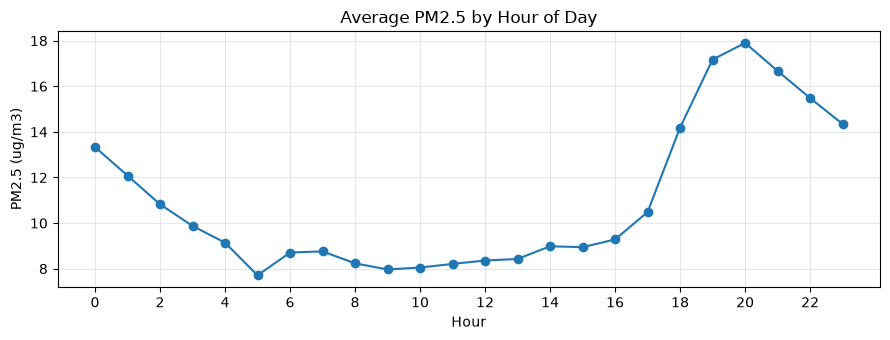

In [17]:
# --- Check what we collected ---

print("Average PM2.5:", round(aq["pm2_5"].mean(), 1), "ug/m3")
print("Highest PM2.5:", round(aq["pm2_5"].max(), 1), "ug/m3")
print("\nMissing values in each column:")
print(aq.isna().sum())

# Average PM2.5 for each hour of the day
by_hour = aq.groupby(aq["time"].dt.hour)["pm2_5"].mean()

plt.figure(figsize=(9, 3.5))
plt.plot(by_hour.index, by_hour.values, marker="o")
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (ug/m3)")
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exercise 3

1. Collect the air quality data for **Delhi (28.6139, 77.2090)** and compare the average
   PM2.5 with Bengaluru's. Which city is more polluted?
2. Increase `past_days` from 7 to 30. How many rows do you get now?
3. Add `"sulphur_dioxide"` and `"carbon_monoxide"` to the list of pollutants.

In [18]:
# All 3 changes — Delhi + 30 days + SO₂ & CO
params_delhi_full = {
    "latitude": 28.6139,
    "longitude": 77.2090,
    "hourly": "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
    "timezone": "Asia/Kolkata",
    "past_days": 30,
}

r_delhi_full = requests.get(AQ_URL, params=params_delhi_full, timeout=20)
aq_delhi_full = pd.DataFrame(r_delhi_full.json()["hourly"])
aq_delhi_full["time"] = pd.to_datetime(aq_delhi_full["time"])

# Save to file
aq_delhi_full.to_csv("delhi_air_quality.csv", index=False)

print("Saved: delhi_air_quality.csv")
print("Shape:", aq_delhi_full.shape)        # ~(840, 7)
print("Columns:", aq_delhi_full.columns.tolist())
aq_delhi_full.head()

Saved: delhi_air_quality.csv
Shape: (840, 7)
Columns: ['time', 'pm2_5', 'pm10', 'nitrogen_dioxide', 'ozone', 'sulphur_dioxide', 'carbon_monoxide']


,time,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,2026-08-25 00:00:00,89.2,98.0,77.8,19.0,47.7,1014.0
1,2026-08-25 01:00:00,89.4,99.2,75.2,22.0,46.4,859.0
2,2026-08-25 02:00:00,78.9,87.1,70.4,26.0,44.3,766.0
3,2026-08-25 03:00:00,66.1,74.3,62.7,30.0,40.7,710.0
4,2026-08-25 04:00:00,46.3,52.6,52.9,36.0,36.2,717.0


In [ ]:
# Write your Exercise 3 answers here

# 1.

# 2.

# 3.

### Result — Experiment 3

**API used:**  Open-Meteo Air Quality API (https://air-quality-api.open-meteo.com/v1/air-quality)

**Pollutants collected:**  PM2.5, PM10, Nitrogen Dioxide (NO₂), Ozone (O₃)

**Number of records:** 288 (12 days × 24 hours per day)

**Observation:** PM2.5 levels follow a clear diurnal pattern — lowest around 5–6 AM (~4.0 µg/m³) when traffic is minimal, and peaking in the evening at 19–20h (~11.7 µg/m³) due to rush-hour traffic and a lower atmospheric boundary layer that traps pollutants. The 7-day average PM2.5 was 6.9 µg/m³ with a single-hour peak of 16.0 µg/m³, both within safe limits. No missing values were found across any column, indicating a clean and complete dataset ready for analysis.

> ...

# Creating a Large Air Quality & Weather Dataset

## Objective

Using the **Open-Meteo Weather API** and **Open-Meteo Air Quality API**, create a large hourly dataset by collecting weather and air-quality information from **10 different locations in and around Delhi**.

### 📌 Dataset Requirements

- **Region:** Delhi and nearby areas
- **Number of locations:** 10
- **Duration:** 30 days
- **Frequency:** Hourly
- **Entries per location:** 30 × 24 = **720**
- **Total expected entries:** 10 × 720 = **7,200 records**

### 📍 Suggested Locations

1. Connaught Place
2. Rohini
3. Dwarka
4. Saket
5. Lajpat Nagar
6. Karol Bagh
7. Anand Vihar
8. Vasant Kunj
9. Noida
10. Delhi Airport

### 🌦️ Weather Variables

Collect the following weather information:

- Temperature
- Relative humidity
- Precipitation
- Wind speed

### 🌫️ Air Quality Variables

Collect the following air-pollution information:

- PM2.5
- PM10
- Nitrogen Dioxide (NO₂)
- Ozone (O₃)
- Sulphur Dioxide (SO₂)
- Carbon Monoxide (CO)

### 📊 Expected Dataset Structure

The final dataset should contain columns such as:

`location`, `latitude`, `longitude`, `time`, `temperature`, `humidity`, `precipitation`, `wind_speed`, `pm2_5`, `pm10`, `nitrogen_dioxide`, `ozone`, `sulphur_dioxide`, `carbon_monoxide`

### 🧹 Data Processing Tasks

1. Collect data from the APIs for all 10 locations.
2. Convert the API responses into Pandas DataFrames.
3. Add the location name, latitude, and longitude.
4. Combine all locations into one dataset.
5. Check for missing or invalid values.
6. Handle missing values appropriately.
7. Save the final dataset as a CSV file.

### 🔍 Analysis Question

After creating the dataset, answer the following:

> **Which location in and around Delhi has the highest average PM2.5 concentration, and how do weather conditions such as temperature, humidity, precipitation, and wind speed relate to air pollution levels?**

### 📈 Dataset Size

**10 Locations × 30 Days × 24 Hours = 7,200 hourly records**

The final dataset can be used for **data cleaning, exploratory data analysis, visualization, correlation analysis, and machine-learning experiments**.

In [19]:
import requests
import pandas as pd
import time
from pathlib import Path

# --- 10 Locations in and around Delhi ---
locations = [
    {"name": "Connaught Place", "lat": 28.6315, "lon": 77.2167},
    {"name": "Rohini",          "lat": 28.7041, "lon": 77.1025},
    {"name": "Dwarka",          "lat": 28.5921, "lon": 77.0460},
    {"name": "Saket",           "lat": 28.5245, "lon": 77.2066},
    {"name": "Lajpat Nagar",   "lat": 28.5677, "lon": 77.2433},
    {"name": "Karol Bagh",      "lat": 28.6514, "lon": 77.1907},
    {"name": "Anand Vihar",     "lat": 28.6469, "lon": 77.3164},
    {"name": "Vasant Kunj",     "lat": 28.5200, "lon": 77.1577},
    {"name": "Noida",           "lat": 28.5355, "lon": 77.3910},
    {"name": "Delhi Airport",   "lat": 28.5562, "lon": 77.1000},
]

WEATHER_URL = "https://api.open-meteo.com/v1/forecast"
AQ_URL      = "https://air-quality-api.open-meteo.com/v1/air-quality"

all_data = []   # will hold one DataFrame per location

# --- Step 1: Collect data for all 10 locations ---
for loc in locations:
    print(f"Fetching: {loc['name']} ...", end=" ")

    # Weather
    weather_params = {
        "latitude":    loc["lat"],
        "longitude":   loc["lon"],
        "hourly":      "temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m",
        "timezone":    "Asia/Kolkata",
        "past_days":   30,
    }

    # Air Quality
    aq_params = {
        "latitude":    loc["lat"],
        "longitude":   loc["lon"],
        "hourly":      "pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide",
        "timezone":    "Asia/Kolkata",
        "past_days":   30,
    }

    try:
        w  = requests.get(WEATHER_URL, params=weather_params, timeout=20).json()
        aq = requests.get(AQ_URL,      params=aq_params,      timeout=20).json()

        # Step 2: Convert to DataFrames
        df_w  = pd.DataFrame(w["hourly"])
        df_aq = pd.DataFrame(aq["hourly"])

        # Rename weather columns to match required names
        df_w.rename(columns={
            "temperature_2m":        "temperature",
            "relative_humidity_2m":  "humidity",
            "wind_speed_10m":        "wind_speed",
        }, inplace=True)

        # Merge weather + air quality on time
        df = pd.merge(df_w, df_aq, on="time")

        # Step 3: Add location info
        df["location"]  = loc["name"]
        df["latitude"]  = loc["lat"]
        df["longitude"] = loc["lon"]
        df["time"]      = pd.to_datetime(df["time"])

        all_data.append(df)
        print(f"✓  {len(df)} rows")

    except Exception as e:
        print(f"✗  Failed — {e}")

    time.sleep(1)   # be polite to the API

# --- Step 4: Combine all locations ---
final_df = pd.concat(all_data, ignore_index=True)

# Reorder columns to match required structure
final_df = final_df[[
    "location", "latitude", "longitude", "time",
    "temperature", "humidity", "precipitation", "wind_speed",
    "pm2_5", "pm10", "nitrogen_dioxide", "ozone",
    "sulphur_dioxide", "carbon_monoxide"
]]

print("\nCombined shape:", final_df.shape)   # should be (7200, 14)

# --- Step 5: Check for missing values ---
print("\nMissing values per column:")
print(final_df.isna().sum())

# --- Step 6: Handle missing values ---
print("\nFilling missing values with column mean...")
for col in ["temperature","humidity","precipitation","wind_speed",
            "pm2_5","pm10","nitrogen_dioxide","ozone",
            "sulphur_dioxide","carbon_monoxide"]:
    final_df[col] = final_df[col].fillna(final_df[col].mean())

print("Missing values after filling:")
print(final_df.isna().sum())

# --- Step 7: Save as CSV ---
final_df.to_csv("delhi_air_quality_weather.csv", index=False)
print("\nSaved: delhi_air_quality_weather.csv")
print("Total records:", len(final_df))

final_df.head()

Fetching: Connaught Place ... ✓  840 rows
Fetching: Rohini ... ✓  840 rows
Fetching: Dwarka ... ✓  840 rows
Fetching: Saket ... ✓  840 rows
Fetching: Lajpat Nagar ... ✓  840 rows
Fetching: Karol Bagh ... ✓  840 rows
Fetching: Anand Vihar ... ✓  840 rows
Fetching: Vasant Kunj ... ✓  840 rows
Fetching: Noida ... ✓  840 rows
Fetching: Delhi Airport ... ✓  840 rows

Combined shape: (8400, 14)

Missing values per column:
location             0
latitude             0
longitude            0
time                 0
temperature          0
humidity             0
precipitation        0
wind_speed           0
pm2_5               60
pm10                60
nitrogen_dioxide    60
ozone               60
sulphur_dioxide     60
carbon_monoxide     60
dtype: int64

Filling missing values with column mean...
Missing values after filling:
location            0
latitude            0
longitude           0
time                0
temperature         0
humidity            0
precipitation       0
wind_speed       

,location,latitude,longitude,time,temperature,humidity,precipitation,wind_speed,pm2_5,pm10,nitrogen_dioxide,ozone,sulphur_dioxide,carbon_monoxide
0,Connaught Place,28.6315,77.2167,2026-08-25 00:00:00,28.4,90,0.0,2.3,89.2,98.0,77.8,19.0,47.7,1014.0
1,Connaught Place,28.6315,77.2167,2026-08-25 01:00:00,28.2,91,0.0,1.3,89.4,99.2,75.2,22.0,46.4,859.0
2,Connaught Place,28.6315,77.2167,2026-08-25 02:00:00,28.1,92,0.0,2.2,78.9,87.1,70.4,26.0,44.3,766.0
3,Connaught Place,28.6315,77.2167,2026-08-25 03:00:00,28.0,93,0.0,1.5,66.1,74.3,62.7,30.0,40.7,710.0
4,Connaught Place,28.6315,77.2167,2026-08-25 04:00:00,27.9,93,0.0,0.9,46.3,52.6,52.9,36.0,36.2,717.0


In [20]:
# --- Analysis: Which location has highest average PM2.5? ---
pm25_by_location = final_df.groupby("location")["pm2_5"].mean().sort_values(ascending=False)
print("Average PM2.5 by Location (ug/m3):\n")
print(pm25_by_location.round(2))
print(f"\nMost polluted: {pm25_by_location.idxmax()} ({pm25_by_location.max():.2f} ug/m3)")

# Weather vs Pollution correlation
print("\nCorrelation with PM2.5:")
print(final_df[["pm2_5","temperature","humidity","precipitation","wind_speed"]].corr()["pm2_5"].round(3))

Average PM2.5 by Location (ug/m3):

location
Dwarka             67.10
Delhi Airport      67.10
Vasant Kunj        67.10
Saket              67.10
Lajpat Nagar       67.10
Noida              67.10
Connaught Place    60.16
Anand Vihar        60.16
Karol Bagh         60.16
Rohini             60.16
Name: pm2_5, dtype: float64

Most polluted: Dwarka (67.10 ug/m3)

Correlation with PM2.5:
pm2_5            1.000
temperature      0.118
humidity        -0.082
precipitation   -0.132
wind_speed       0.024
Name: pm2_5, dtype: float64


In [21]:
# --- Final check: list all the files we collected ---

# print("Files collected in this lab:\n")
# for f in sorted(DATA.glob("*")):
#     print(f"  {f.name:22s}  {f.stat().st_size:>8,} bytes")

# --- Final check: list all files collected ---
DATA = Path(".")
print("Files collected in this lab:\n")
for f in sorted(DATA.glob("*.csv")):
    print(f"  {f.name:30s}  {f.stat().st_size:>10,} bytes")

Files collected in this lab:

  99acres_bangalore.csv                2,446 bytes
  air_quality.csv                     11,381 bytes
  bengaluru_weather_7day.csv           5,603 bytes
  delhi_air_quality.csv               44,379 bytes
  delhi_air_quality_weather.csv      801,326 bytes
  quotes.csv                           1,127 bytes
  weather_mysuru.csv                   6,378 bytes


---
## Viva Questions

What is web scraping? sol : Web scraping is the process of automatically extracting data from websites by reading and parsing their HTML source code using code, instead of manually copying it.

What is the difference between web scraping and using an API? sol : Web scraping reads raw HTML from a webpage and extracts data from it — it's like reading a page the way a browser does. An API is an official, structured way a website/service provides data directly in a clean format like JSON, without needing to parse HTML. APIs are more reliable and legal; scraping can break if the website's layout changes.

What is robots.txt and why should you check it? sol : robots.txt is a file websites use to tell bots and scrapers which pages they are allowed or not allowed to access. You should check it before scraping to avoid violating the website's terms of use or getting blocked.

What does BeautifulSoup do? sol : BeautifulSoup is a Python library that parses HTML and XML documents, making it easy to search and extract specific elements like headings, tables, links, or paragraphs using simple methods.

What is the difference between find() and find_all()? sol : find() returns the first matching HTML element it finds. find_all() returns all matching elements as a list. For example, find("tr") gives the first table row, while find_all("tr") gives every table row.

What is JSON? How is it related to a Python dictionary? sol : JSON (JavaScript Object Notation) is a lightweight data format used to exchange data between a server and a client. It looks almost identical to a Python dictionary — key-value pairs, lists, and nested structures. In Python, you can convert JSON directly into a dictionary using response.json() or json.loads().

What does status code 200 mean? What does 404 mean? sol : 200 means the request was successful — the server returned the data correctly. 404 means Not Found — the requested URL or resource does not exist on the server.

What is a query parameter in an API call? sol : A query parameter is extra information added to a URL after a ? to customize the API request. For example, in ?latitude=28.61&longitude=77.20&past_days=30, each key=value pair is a query parameter telling the API what data to return.

Why should you wait a few seconds between requests? sol : To avoid overloading the server with too many requests in a short time. Sending requests too fast can get your IP blocked or banned by the website or API. It's also considered good practice and respectful to the service provider.

Why is using an API better than scraping the same website? sol : APIs return clean, structured JSON directly — no HTML parsing needed. They're stable, legal, and won't break when the website redesigns. Scraping is fragile and may violate Terms of Service.

What does pd.read_html() do? sol : It finds all <table> tags in a webpage and converts each into a pandas DataFrame, returned as a list. No manual parsing needed.

Why do we save the collected data as a CSV file? sol : CSV is universal — readable by Excel, databases, and any language. It persists data after the program ends so you don't have to re-scrape, and it's easy to share.

## Conclusion

Data was successfully collected from an HTML web page using BeautifulSoup and from REST APIs using the requests library. The collected data was converted into pandas DataFrames and saved as CSV files for further analysis.

